In [1]:
import nltk
import numpy as np
import pandas as pd
import os
import re
import json
import string
import Basic_functions as bf  #Homemade script.
import time
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colormaps

from nltk import word_tokenize
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from scipy import sparse
from scipy.stats import chisquare, t

import torch
import torch.nn as nn
import torch.optim as optim

###################################################

#https://gist.github.com/berteltorp/0cf8a0c7afea7f25ed754f24cfc2467b Stopords liste
stopwords_danish = np.genfromtxt(r"txt_files\\stopord.txt", dtype = "str", encoding="utf-8")
default_stopwords = set(stopwords.words('english'))

extended_stopwords = default_stopwords.union(stopwords_danish)

print('Packages loaded')

Packages loaded


<h1> Importing the files.</h1>
for 36000 files, takes roughly 7 minuttes

<h1> Preprocessing the files</h1>
takes roughly 192.493180 seconds

In [2]:
df_clean = pd.read_csv(r'NLTK_clean_all.csv', 
                       na_values=['', 'nan', 'NAN'],
                        sep = ";",
                        encoding='utf-8',
                        )
df_clean['text'] = df_clean['text'].fillna('')
df_clean['text'] = df_clean['text'].astype(str)
filter_art = (df_clean['text_type'].values == 1)
df_clean = df_clean[filter_art]
df_clean = df_clean[df_clean['text'].str.strip().astype('bool')]

In [3]:
sort_idx = np.genfromtxt(r"..\regression_nltk_sort_idx.txt")
print(sort_idx)

[46327. 26748. 50083. ... 64443. 64442. 64466.]


In [53]:
df_clean

,text,length,LIX,topic,text_type,year
4758,kong mænd populistisk idealistisk politik sælg...,512,42.781395,Kultur,1,2004.424886
4763,glæded att frie mennesk hurt vend tank misted ...,2168,41.395107,Danmark,1,2003.157306
4765,dansk ungdomsfilm bagland deltog copenhag inte...,1074,46.485799,Kultur,1,2003.993379
4766,politik lørdag udnyt grundlovssikred ytringsfr...,2997,48.242836,Økonomi,1,2001.388128
4767,seer tidsrum klok svar fordobling gennemsnit s...,2357,46.855868,Kultur,1,2001.444064
...,...,...,...,...,...,...
857807,europæisk klimakorrespondent blåt klistermærk ...,216,50.000000,Kultur,1,2009.935845
857808,journalist person bord amerikansk militærfly d...,217,45.952381,Internationalt,1,2010.662785
857809,opfindsom medi handl driv gæk lyt seer april f...,244,35.694444,Kultur,1,2010.336073
857810,sofaspil sæt eget vmhold vind flot præmi,51,42.333333,Danmark,1,2010.527397


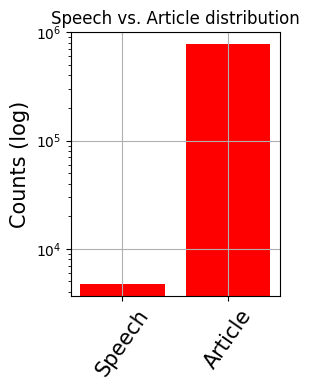

In [104]:
label, counts = np.unique(df_clean['text_type'].values, return_counts = True)
plt.figure(figsize=(3,4))
plt.yscale('log')
plt.xticks(rotation = 55, fontsize = 15)
plt.ylabel('Counts (log)', fontsize = 15)
plt.title('Speech vs. Article distribution')
plt.grid()
plt.bar(['Speech', 'Article'], counts, color = 'red')
plt.tight_layout()

In [4]:
Topics, counts= np.unique(df_clean['topic'].astype(str).values, return_counts=True)
Top_counts = counts[np.argsort(counts)][-10:]
Top_topics = Topics[np.argsort(counts)[-10:]]
df_topic_sort = df_clean.loc[df_clean['topic'].isin(Top_topics)]
random_sample = df_topic_sort.sample(n=100)
print(np.unique(random_sample['topic'].values, return_counts = True))
#['Cykling', 'Danmark', 'Film og tv', 'Fodbold', 'Forbrug', 'Internationalt', 'Kultur', 'Politik', 'Sport', 'Økonomi']

(array(['Cykling', 'Danmark', 'Film og tv', 'Fodbold', 'Forbrug',
       'Internationalt', 'Kultur', 'Politik', 'Sport', 'Økonomi'],
      dtype=object), array([ 3, 30,  1,  9,  4, 24,  4,  9,  8,  8]))


C:\Users\Geniet\AppData\Local\Temp\ipykernel_5900\2769959277.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(G_label[:])
C:\Users\Geniet\AppData\Local\Temp\ipykernel_5900\2769959277.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(G_label)


Accuracy score:0.62


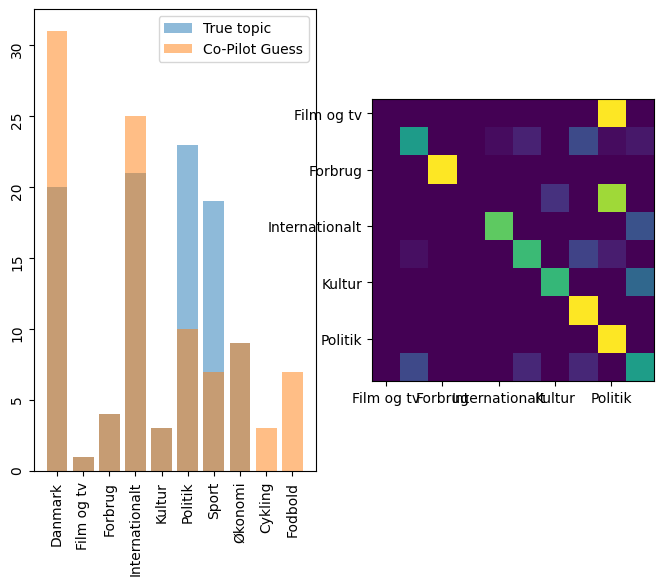

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay 
#print(random_sample['topic'].values[99])
#print(random_sample['text'].values[99])

Guess = np.array(['Politik', 'Politik', 'Politik','Forbrug', 'Internationalt','Politik', 'Internationalt',
                 'Danmark', 'Internationalt','Økonomi', 'Danmark', 'Danmark', 'Sport', 'Økonomi', 'Politik',
                 'Sport', 'Sport', 'Internationalt', 'Internationalt', 'Politik', 'Internationalt', 'Sport',
                 'Politik', 'Sport', 'Sport', 'Politik', 'Politik', 'Politik', 'Sport', 'Danmark',
                 'Økonomi', 'Politik', 'Internationalt', 'Internationalt', 'Økonomi', 'Danmark', 'Danmark',
                 'Danmark', 'Internationalt', 'Internationalt', 'Økonomi', 'Sport', 'Danmark', 'Danmark',
                 'Danmark', 'Danmark', 'Internationalt', 'Danmark', 'Danmark', 'Danmark', 'Sport', 'Sport', 'Kultur',
                 'Danmark', 'Sport', 'Kultur', 'Økonomi', 'Danmark', 'Politik', 'Internationalt', 'Sport', 'Kultur', 'Danmark',
                 'Danmark', 'Sport', 'Forbrug', 'Internationalt', 'Politik', 'Internationalt', 'Politik', 'Politik', 'Danmark',
                 'Politik', 'Forbrug', 'Internationalt', 'Økonomi', 'Politik', 'Sport', 'Sport', 'Politik', 'Film og tv', 'Politik',
                 'Sport', 'Politik', 'Politik', 'Økonomi', 'Forbrug', 'Sport', 'Internationalt', 'Danmark', 'Sport',
                 'Internationalt', 'Politik', 'Internationalt', 'Internationalt', 'Sport', 'Internationalt', 'Politik', 'Internationalt',
                 'Økonomi'])

true = np.array(['Danmark', 'Politik','Politik','Danmark', 'Internationalt', 'Internationalt', 'Økonomi',
                'Danmark', 'Danmark','Økonomi', 'Danmark', 'Danmark', 'Fodbold', 'Forbrug', 'Politik',
                'Sport', 'Sport', 'Internationalt', 'Internationalt', 'Internationalt', 'Internationalt', 'Sport',
                'Danmark', 'Sport', 'Internationalt', 'Politik', 'Politik', 'Politik', 'Sport', 'Internationalt',
                'Økonomi', 'Politik', 'Internationalt', 'Internationalt', 'Danmark', 'Økonomi', 'Danmark',
                'Danmark', 'Internationalt', 'Internationalt', 'Økonomi', 'Fodbold', 'Danmark', 'Danmark', 'Danmark',
                'Danmark', 'Internationalt', 'Danmark', 'Danmark', 'Danmark', 'Danmark', 'Sport', 'Kultur',
                'Danmark', 'Cykling', 'Fodbold', 'Kultur', 'Danmark', 'Danmark', 'Internationalt', 'Cykling', 'Kultur', 'Danmark',
                'Økonomi', 'Cykling', 'Forbrug', 'Internationalt', 'Danmark', 'Internationalt', 'Danmark', 'Politik', 'Danmark',
                'Politik', 'Forbrug', 'Internationalt', 'Danmark', 'Internationalt', 'Fodbold', 'Fodbold', 'Internationalt', 'Film og tv',
                'Danmark', 'Fodbold', 'Politik', 'Økonomi', 'Økonomi', 'Forbrug',
                 'Sport', 'Internationalt', 'Danmark', 'Internationalt',
                'Internationalt', 'Internationalt', 'Danmark', 'Danmark', 
                 'Fodbold', 'Internationalt', 'Danmark', 'Internationalt', 'Økonomi'])

G_label, G_count = np.unique(Guess, return_counts=True)
T_label, T_count = np.unique(true, return_counts=True)
cm = confusion_matrix(true, Guess, normalize='true')
disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=G_label
                             )
fig, ax = plt.subplots(1,2, figsize = (8,6))
ax[0].bar(G_label, G_count, label='True topic', alpha = 0.5)
ax[0].bar(T_label, T_count, label = 'Co-Pilot Guess', alpha = 0.5)
ax[0].tick_params(labelrotation=90)
ax[0].legend()
ax[1].imshow(cm)
#ax[1].set_xticks([0,1,2,3,4,5,6,7,8,9])
ax[1].set_yticklabels(G_label[:])
ax[1].set_xticklabels(G_label)
plt.tight_layout

print(f'Accuracy score: {accuracy_score(true, Guess)}')

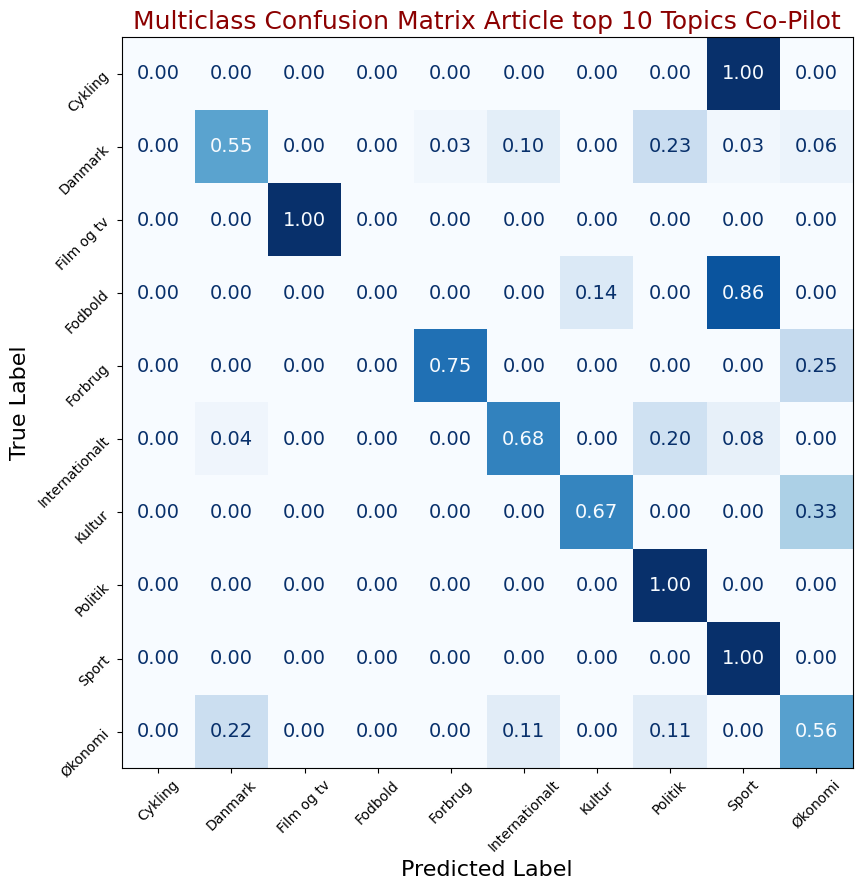

In [53]:
cm = confusion_matrix(
    true,
    Guess,
    normalize="true"
)

# Force 2 decimals
cm = np.round(cm, 2)

classes = T_label

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    xticks_rotation=0,
    cmap=plt.cm.Blues,
    colorbar=False,

    values_format=".2f"   # FORCE 2 DECIMALS
)

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Multiclass Confusion Matrix Article top 10 Topics Co-Pilot",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "Predicted Label",
    fontsize=16
)
plt.xticks(rotation = 45)

plt.ylabel(
    "True Label",
    fontsize=16
)
plt.yticks(rotation = 45)
plt.tight_layout()
plt.show()

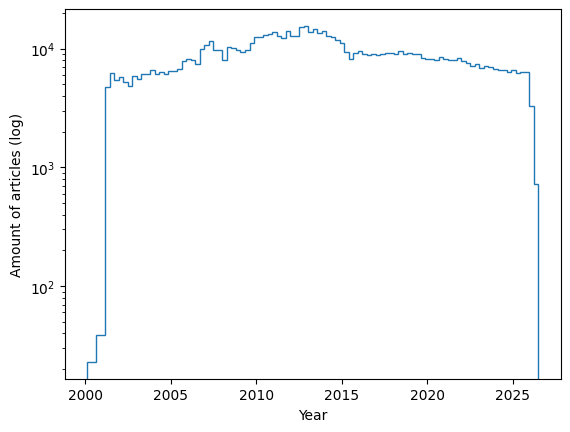

In [62]:
plt.hist(df_clean['year'], bins = 100, histtype = 'step')
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('Amount of articles (log)')
plt.show()

In [23]:
df_clean.dtypes

text       object
length      int64
topic      object
LIX       float64
year      float64
dtype: object

<h1> Embedding the data</h1>
TF_IDF turns the words into a sparse matrix, weighing the words. Biased by text length, though.

In [180]:
from scipy.sparse import hstack, csr_matrix

#min_df=25, max_df=0.8,
vectorizer = TfidfVectorizer(use_idf=True,lowercase=True, min_df=100, max_df=0.6, token_pattern=r'(?u)\b[A-Za-zæøå]+\b')
#Term Frequency-Inverse Document Frequency)

#Word2vec is better https://www.geeksforgeeks.org/python/python-word-embedding-using-word2vec/

#X_lix = csr_matrix(df_clean[['LIX']].astype(float).values)
#X_len = csr_matrix(df_clean[['length']].astype(float).values)
X_text = (vectorizer.fit_transform(df_topic_sort['text'])).astype(np.float32)

X = X_text #hstack([X_text, X_lix, X_len]) #,X_sermon])
#X = X[:,sort_idx][0:20000]
y = df_topic_sort['year']
print(f"Sparsity: {X.nnz / np.prod(X.shape):.3f}")
print("TF-IDF matrix shape:", X.shape)

Sparsity: 0.003
TF-IDF matrix shape: (434564, 16625)


In [51]:
vectorizer.get_feature_names_out()

array(['aab', 'aabenraa', 'aaberg', ..., 'øvet', 'øvig', 'øvr'],
      dtype=object)

In [61]:
for i in range(200):
    print(vectorizer.get_feature_names_out()[100*i:100*i+100]) #[sort_idx[0:20000].astype(int)][100*i:100*i+100])

['aab' 'aabenraa' 'aaberg' 'aabspil' 'aabtræn' 'aaen' 'aag' 'aagaard'
 'aakeson' 'aakjær' 'aalborg' 'aalborgens' 'aalbæk' 'aaman' 'aamund' 'aar'
 'aarestrup' 'aarhus' 'aarhusian' 'aarhusiansk' 'aaron' 'aarup' 'aarø'
 'aas' 'aastrup' 'abba' 'abbey' 'abbot' 'abc' 'abdel' 'abdi' 'abdic'
 'abdolhamid' 'abdul' 'abdulhadi' 'abdullah' 'abe' 'abel' 'aben' 'aber'
 'aberde' 'abern' 'abildgaard' 'abl' 'abon' 'abonnement' 'abonnent'
 'abort' 'abortmodstand' 'abraham' 'abrahams' 'abrupt' 'abs' 'absalon'
 'absalons' 'absentia' 'absolut' 'absorb' 'abstinens' 'abstrak'
 'abstraktion' 'absurd' 'absurdit' 'absurditet' 'abu' 'academy' 'acceler'
 'acceleration' 'accent' 'accept' 'acceptabel' 'acceptabelt' 'acceptabl'
 'according' 'account' 'acqua' 'acros' 'act' 'action' 'actionfilm'
 'actionspil' 'actually' 'adam' 'adams' 'add' 'adding' 'addis' 'ade'
 'adel' 'adelaid' 'adelskov' 'adelsmærk' 'adfærd' 'adgang' 'adgangsbil'
 'adgangskort' 'adgangskrav' 'adhanom' 'adhd' 'adida']
['adjung' 'adjunk' 'adl' 'adle

<h1> Dimensionality reduction</h1>

In [184]:
svd = TruncatedSVD(n_components=2,
             algorithm='randomized',
             n_iter=10,
             n_oversamples=10,
             power_iteration_normalizer='auto',
             random_state=42,
             )

start = time.time()

X_LSA = svd.fit_transform(X)
print(svd.explained_variance_ratio_)
print(svd.explained_variance_ratio_.sum())
print(svd.singular_values_)

stop = time.time()
print(f'Done in {stop-start:3f} seconds', '\n')

[0.00259913 0.00541946]
0.008018586
[73.399124 48.32884 ]
Done in 4.620292 seconds 



10


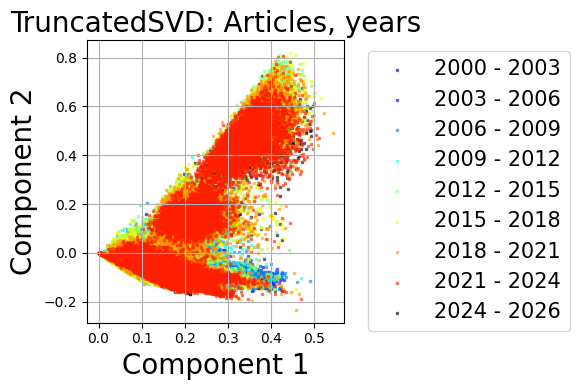

In [178]:
step = 3
intervals = np.arange(2000,2030,step)
intervals[-1] = 2026
print(len(intervals))

try:
    # Create cutoffs column
    df_clean['cutoffs'] = pd.cut(
        df_clean['year'],
        intervals,
        labels=intervals[:-1],
        right=False
    )

    # Verify the column was created
    if 'cutoffs' not in df_clean.columns:
        raise ValueError("Failed to create 'cutoffs' column")
        
    # Create scatter plot
    
    plt.figure(figsize=(6, 4), )
    cutoffs = df_clean['cutoffs'].cat.categories
    final_cut = cutoffs[-1]
    colors = cm.jet(np.linspace(0, 1, len(cutoffs)))

    mask_final = df_clean['cutoffs'] == final_cut
    if mask_final.sum() > 0:  # Only plot if there are points
        plt.scatter(
            X_LSA[mask_final, 0],
            X_LSA[mask_final, 1],
            marker=',',
            s = 1,
            label=f'{str(final_cut)} - {str(2026)}',
            alpha=0.5,
            color='black'
        )

    for i, cutoff in enumerate(df_clean['cutoffs'].cat.categories[:-1]):
        subX_LSA = X_LSA[df_clean['cutoffs'] == cutoff, :]
        plt.scatter(
            subX_LSA[:,0],
            subX_LSA[:,1],
            marker=',',
            s = 1,
            label=f'{str(cutoff)} - {str(cutoff + step)}',
            alpha=0.5,
            color=colors[i]  # Use corresponding color from the colormap
        )


    plt.title('TruncatedSVD: Articles, years', fontsize=20)
    plt.gca().set_xlabel('Component 1', fontsize=20)
    plt.gca().set_ylabel('Component 2', fontsize=20)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = [1,2,3,4,5,6,7,8,0]

    
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 15)
    plt.tight_layout()
    plt.grid()
    plt.show()

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nDebugging info:")
    print(f"DataFrame columns: {df_clean.columns.tolist()}")
    print(f"DataFrame shape: {df_clean.shape}")
    print(f"Sample of year values: {df_clean['year'].head()}")

7


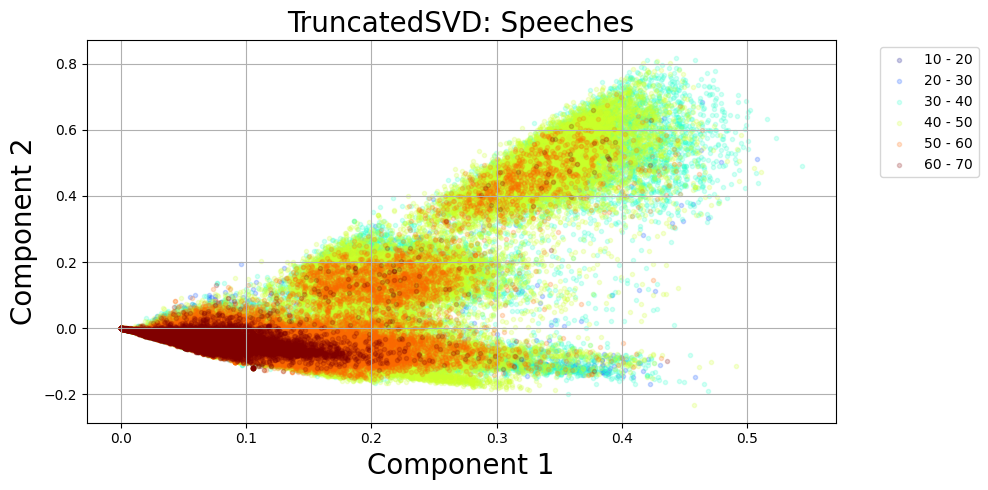

In [150]:
step = 10
intervals = np.arange(10,80,step)
print(len(intervals))

try:
    # Create cutoffs column
    df_clean['LIX_cutoffs'] = pd.cut(
        df_clean['LIX'],
        intervals,
        labels=intervals[:-1],
        right=False
    )

    # Verify the column was created
    if 'LIX_cutoffs' not in df_clean.columns:
        raise ValueError("Failed to create 'cutoffs' column")
        
    # Create scatter plot
    
    plt.figure(figsize=(10, 5), )
    colors = cm.jet(np.linspace(0, 1, len(df_clean['LIX_cutoffs'].cat.categories)))

    for i, cutoff in enumerate(df_clean['LIX_cutoffs'].cat.categories[:]):
        subX_LSA = X_LSA[df_clean['LIX_cutoffs'] == cutoff, :]
        plt.scatter(
            subX_LSA[:,0],
            subX_LSA[:,1],
            marker='.',
            label=f'{str(cutoff)} - {str(cutoff + step)}',
            alpha=0.2,
            color=colors[i]  # Use corresponding color from the colormap
        )


    plt.title('TruncatedSVD: Speeches', fontsize=20)
    plt.gca().set_xlabel('Component 1', fontsize=20)
    plt.gca().set_ylabel('Component 2', fontsize=20)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = [0,1,2,3,4,5]

    
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid()
    plt.show()

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nDebugging info:")
    print(f"DataFrame columns: {df_clean.columns.tolist()}")
    print(f"DataFrame shape: {df_clean.shape}")
    print(f"Sample of year values: {df_clean['year'].head()}")

C:\Users\Geniet\AppliedML\AppliedML2026\appmlenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


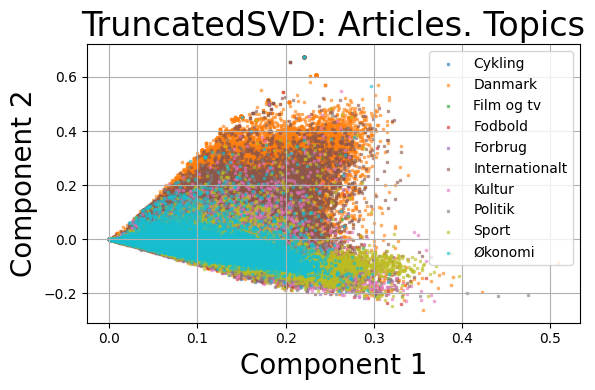

In [212]:
plt.figure(figsize=(6, 4))
for i in np.unique(df_topic_sort['topic'].values):
    plt.scatter(X_LSA[df_topic_sort['topic'].values == i,0], X_LSA[df_topic_sort['topic'].values == i,1],
                marker = ',', 
                alpha = 0.5,
                s = 1,
                label = (f"{i}"))
#plt.scatter(X_LSA[ is_serm == 0,0], X_LSA[is_serm == 0,1], marker = '.', label = 'Speech')
#plt.scatter(X_LSA[:,0], X_LSA[:,1],marker = '.', c = df_sermon.values, alpha=1)
plt.title('TruncatedSVD: Articles. Topics', fontsize=24)
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

<h2> </h2>

In [58]:
import umap

reducer = umap.UMAP(n_neighbors= 5) #, min_dist= 1.0)

embedding = reducer.fit_transform(X)

C:\Users\Geniet\AppliedML\AppliedML2026\appmlenv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


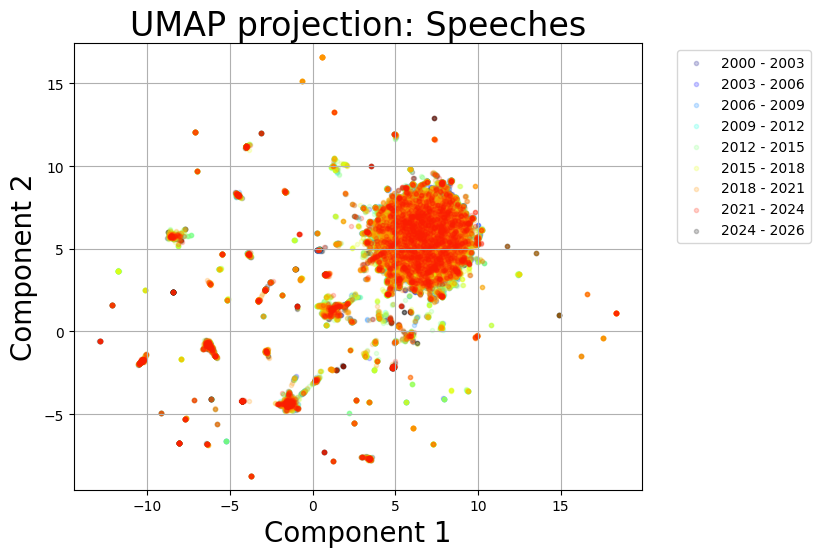

In [64]:
plt.figure(figsize = (8,5))
final_cut = df_clean['cutoffs'].cat.categories[-1]
colors = cm.jet(np.linspace(0, 1, len(df_clean['cutoffs'].cat.categories)))

step = 3

plt.scatter(
        embedding[df_clean['cutoffs'] == final_cut, 0],
        embedding[df_clean['cutoffs'] == final_cut, 1],
        marker='.',
        label=f'{str(final_cut)} - {str(2026)}',
        alpha=0.2,
        color='black' #colors[-1]  # Last color in the jet colormap
    )

for i, cutoff in enumerate(df_clean['cutoffs'].cat.categories[:-1]):
    subembedding = embedding[df_clean['cutoffs'] == cutoff, :]
    plt.scatter(
        subembedding[:,0],
        subembedding[:,1],
        marker='.',
        label=f'{str(cutoff)} - {str(cutoff + step)}',
        alpha=0.2,
        color=colors[i]  # Use corresponding color from the colormap
    )

handles, labels = plt.gca().get_legend_handles_labels()
order = [1,2,3,4,5,6,7,8,0]

plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection: Speeches', fontsize=24);
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
plt.grid()
plt.show()

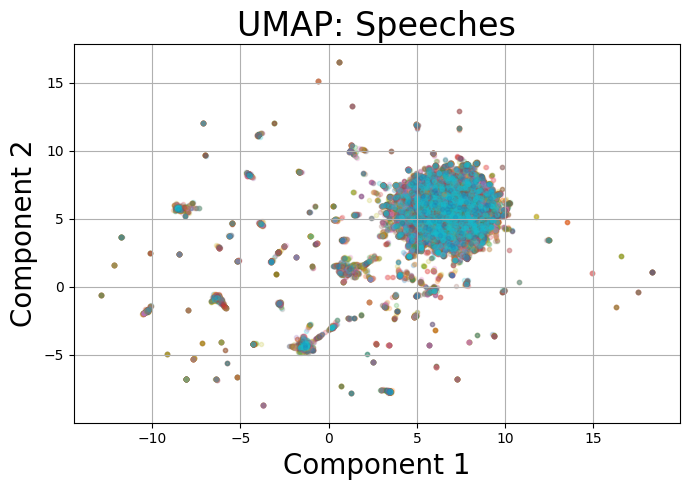

In [60]:
plt.figure(figsize=(7, 5))
for i in np.unique(df_clean['topic'].values):
    plt.scatter(embedding[df_clean['topic'].values == i,0],
                embedding[df_clean['topic'].values == i,1], 
                marker = '.', label = [df_clean['topic'].values == i], alpha = 0.2)
    
plt.title('UMAP: Speeches', fontsize=24)
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
#plt.scatter(embedding[:,0], embedding[:,1], c = df_labels['sermon'].values)

<h1>XGboost model training</h1>

In [63]:
from sklearn.preprocessing import LabelEncoder

svd = TruncatedSVD(n_components=100,
             algorithm='randomized',
             n_iter=5,
             n_oversamples=10,
             power_iteration_normalizer='auto',
             random_state=42,
             )

#le = LabelEncoder()

X_LSA = svd.fit_transform(X)
#y = le.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(X_LSA, y, test_size=0.20, random_state=42)
X_eval, X_test, y_eval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

_, X_sample, _ , y_sample = train_test_split(X_train, y_train, test_size = 50000) #Creating a sample to optimise over.
print('Done')
print("Explained variance:", svd.explained_variance_ratio_.sum())

Done
Explained variance: 0.115489475


In [489]:
print("Explained variance:", svd.explained_variance_ratio_.sum())

Explained variance: 0.7386996


In [53]:
#from sklearn.preprocessing import LabelEncoder
#le = LabelEncoder()
#y_train = le.fit_transform(y_train)
#n_estimators=200,
#                         learning_rate=0.29,
#                         max_depth = 11,
#                         reg_alpha = 0.7,
#                         reg_lambda = 0.82,
#                         gamma = 0.63,
#                         subsample = 0.93,

In [82]:
import xgboost as xgb
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_squared_error, r2_score
from optuna.samplers import TPESampler
print('running xgboost version:', xgb.__version__)

evalset = [(X_sample, y_sample),(X_eval, y_eval)]

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 700),  # More trees
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10),  # Slower learning
        "max_depth": trial.suggest_int("max_depth", 4, 15, log = True),  # Shallower trees
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 8),  # Less conservative
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),  # Less aggressive
        "reg_alpha": trial.suggest_float("reg_alpha", 0.3, 0.8),  # Moderate L1
        "reg_lambda": trial.suggest_float("reg_lambda", 0.3, 0.9),  # Moderate L2
        "subsample": trial.suggest_float("subsample", 0.6, 0.99),  # More data per tree
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 0.99),  # More features
    }

    model = xgb.XGBRegressor(objective='reg:squarederror',
                         eval_metric = 'rmse',
                         importance_type="weight",
                         **params,
                         n_jobs = 2,
                         tree_method = 'hist',
                         early_stopping_rounds = 40,
                         grow_policy = 'lossguide',
                         max_bin = 64,
                         random_state=42)
    
    model.fit(X_sample, y_sample, eval_set= evalset, verbose=2)
    y_pred = model.predict(X_eval)
    R2 = r2_score(y_eval, y_pred)
    #mse = mean_squared_error(y_eval, y_pred)
    #mse_train = mean_squared_error(y_sample, model.predict(X_sample))
    return(-R2)


#################################################
#study_name = "NLTK_reg_Art-study"
#storage_name = f"sqlite:///{study_name}.db"
#optuna.delete_study(study_name=study_name, storage=storage_name)

study_reg = optuna.create_study(
    #study_name=study_name,
    #storage=storage_name,
    #load_if_exists=True,
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    sampler=TPESampler(seed = 42, n_startup_trials=5),
                               )

study_reg.optimize(objective, n_trials = 20)

print("Best hyperparameters:", study_reg.best_params)
print("Best accuracy:", study_reg.best_value)


[I 2026-06-08 10:38:58,550] A new study created in memory with name: no-name-87670344-8d10-42cf-9814-e3f9cdcf9557


running xgboost version: 3.0.0
[0]	validation_0-rmse:5.58396	validation_1-rmse:5.68740
[2]	validation_0-rmse:5.06073	validation_1-rmse:5.35429
[4]	validation_0-rmse:4.67663	validation_1-rmse:5.19280
[6]	validation_0-rmse:4.33287	validation_1-rmse:5.09041
[8]	validation_0-rmse:4.00388	validation_1-rmse:5.04591
[10]	validation_0-rmse:3.73000	validation_1-rmse:5.02090
[12]	validation_0-rmse:3.50146	validation_1-rmse:5.00798
[14]	validation_0-rmse:3.28460	validation_1-rmse:4.99816
[16]	validation_0-rmse:3.13002	validation_1-rmse:4.98593
[18]	validation_0-rmse:2.97988	validation_1-rmse:4.98609
[20]	validation_0-rmse:2.84298	validation_1-rmse:4.98864
[22]	validation_0-rmse:2.67986	validation_1-rmse:4.99423
[24]	validation_0-rmse:2.54870	validation_1-rmse:4.99724
[26]	validation_0-rmse:2.39721	validation_1-rmse:4.99856
[28]	validation_0-rmse:2.27325	validation_1-rmse:5.00058
[30]	validation_0-rmse:2.17671	validation_1-rmse:5.00066
[32]	validation_0-rmse:2.07122	validation_1-rmse:5.00377
[34]	

[I 2026-06-08 10:39:19,525] Trial 0 finished with value: -0.3011500552913058 and parameters: {'n_estimators': 387, 'learning_rate': 0.28570714885887566, 'max_depth': 10, 'min_child_weight': 6, 'gamma': 1.2481491235394921, 'reg_alpha': 0.3779972601681013, 'reg_lambda': 0.33485016730091965, 'subsample': 0.9378086968522248, 'colsample_bytree': 0.9142118522312097}. Best is trial 0 with value: -0.3011500552913058.


[0]	validation_0-rmse:5.89483	validation_1-rmse:5.94017
[2]	validation_0-rmse:5.81420	validation_1-rmse:5.89394
[4]	validation_0-rmse:5.73969	validation_1-rmse:5.85204
[6]	validation_0-rmse:5.66025	validation_1-rmse:5.80899
[8]	validation_0-rmse:5.58639	validation_1-rmse:5.76782
[10]	validation_0-rmse:5.51049	validation_1-rmse:5.72818
[12]	validation_0-rmse:5.44567	validation_1-rmse:5.69275
[14]	validation_0-rmse:5.37153	validation_1-rmse:5.65572
[16]	validation_0-rmse:5.30043	validation_1-rmse:5.62105
[18]	validation_0-rmse:5.22929	validation_1-rmse:5.58765
[20]	validation_0-rmse:5.16405	validation_1-rmse:5.55521
[22]	validation_0-rmse:5.10359	validation_1-rmse:5.52493
[24]	validation_0-rmse:5.03567	validation_1-rmse:5.49479
[26]	validation_0-rmse:4.98077	validation_1-rmse:5.46660
[28]	validation_0-rmse:4.92410	validation_1-rmse:5.43988
[30]	validation_0-rmse:4.86814	validation_1-rmse:5.41356
[32]	validation_0-rmse:4.81387	validation_1-rmse:5.38891
[34]	validation_0-rmse:4.75402	valid

[I 2026-06-08 10:47:21,977] Trial 1 finished with value: -0.38993788220015146 and parameters: {'n_estimators': 554, 'learning_rate': 0.01596950334578271, 'max_depth': 15, 'min_child_weight': 7, 'gamma': 1.6987128854262092, 'reg_alpha': 0.3909124836035503, 'reg_lambda': 0.41004270591206027, 'subsample': 0.7186544747542197, 'colsample_bytree': 0.8997037220101252}. Best is trial 1 with value: -0.38993788220015146.


...

[0]	validation_0-rmse:5.82977	validation_1-rmse:5.86723
[2]	validation_0-rmse:5.66223	validation_1-rmse:5.72040
[4]	validation_0-rmse:5.50801	validation_1-rmse:5.59458
[6]	validation_0-rmse:5.36373	validation_1-rmse:5.48182
[8]	validation_0-rmse:5.26268	validation_1-rmse:5.40274
[10]	validation_0-rmse:5.14364	validation_1-rmse:5.32025
[12]	validation_0-rmse:5.05053	validation_1-rmse:5.26499
[14]	validation_0-rmse:4.95573	validation_1-rmse:5.21210
[16]	validation_0-rmse:4.87287	validation_1-rmse:5.16117
[18]	validation_0-rmse:4.79478	validation_1-rmse:5.11830
[20]	validation_0-rmse:4.72843	validation_1-rmse:5.08437
[22]	validation_0-rmse:4.66970	validation_1-rmse:5.06010
[24]	validation_0-rmse:4.61117	validation_1-rmse:5.03228
[26]	validation_0-rmse:4.55091	validation_1-rmse:5.00782
[28]	validation_0-rmse:4.48996	validation_1-rmse:4.98529
[30]	validation_0-rmse:4.43350	validation_1-rmse:4.96610
[32]	validation_0-rmse:4.37491	validation_1-rmse:4.94576
[34]	validation_0-rmse:4.33043	valid

[I 2026-06-08 11:13:17,869] Trial 18 finished with value: -0.37853798750323375 and parameters: {'n_estimators': 615, 'learning_rate': 0.10410388914225194, 'max_depth': 8, 'min_child_weight': 7, 'gamma': 5.828259670918077, 'reg_alpha': 0.32226731812977816, 'reg_lambda': 0.7053591770342109, 'subsample': 0.7759973533202098, 'colsample_bytree': 0.8248066480271067}. Best is trial 14 with value: -0.4027794006786305.


[0]	validation_0-rmse:5.85316	validation_1-rmse:5.88309
[2]	validation_0-rmse:5.73511	validation_1-rmse:5.76974
[4]	validation_0-rmse:5.63409	validation_1-rmse:5.67615
[6]	validation_0-rmse:5.54656	validation_1-rmse:5.59806
[8]	validation_0-rmse:5.46207	validation_1-rmse:5.52281
[10]	validation_0-rmse:5.38155	validation_1-rmse:5.45124
[12]	validation_0-rmse:5.32553	validation_1-rmse:5.40448
[14]	validation_0-rmse:5.26605	validation_1-rmse:5.35608
[16]	validation_0-rmse:5.21883	validation_1-rmse:5.31821
[18]	validation_0-rmse:5.17794	validation_1-rmse:5.28501
[20]	validation_0-rmse:5.13443	validation_1-rmse:5.25032
[22]	validation_0-rmse:5.09785	validation_1-rmse:5.22375
[24]	validation_0-rmse:5.06824	validation_1-rmse:5.20195
[26]	validation_0-rmse:5.03869	validation_1-rmse:5.18073
[28]	validation_0-rmse:5.01021	validation_1-rmse:5.16063
[30]	validation_0-rmse:4.97817	validation_1-rmse:5.13820
[32]	validation_0-rmse:4.94970	validation_1-rmse:5.11859
[34]	validation_0-rmse:4.92333	valid

[I 2026-06-08 11:13:40,471] Trial 19 finished with value: -0.37873994646581044 and parameters: {'n_estimators': 487, 'learning_rate': 0.13005600043678356, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 3.478364524458254, 'reg_alpha': 0.44202202313873107, 'reg_lambda': 0.6571201646835897, 'subsample': 0.6641503374536637, 'colsample_bytree': 0.8065448036111053}. Best is trial 14 with value: -0.4027794006786305.


NameError: name 'study' is not defined

In [88]:
#study_reg = optuna.create_study(study_name = study_name, 
#                            storage = storage_name,
#                            load_if_exists=True,
#                           )

print("Best trial:")
trial = study_reg.best_trial
print(f"  MSE: {-trial.values[0]}")
#print(f"  Accuracy: {-trial.values[1]}") 

print("Best hyperparameters:", study_reg.best_params)
#print("Best accuracy:", study.best_value)

Best trial:
  MSE: 0.4027794006786305
Best hyperparameters: {'n_estimators': 629, 'learning_rate': 0.0488675210771383, 'max_depth': 8, 'min_child_weight': 7, 'gamma': 2.8205642931377213, 'reg_alpha': 0.41304793629469266, 'reg_lambda': 0.5075533776181534, 'subsample': 0.776927608942612, 'colsample_bytree': 0.836434605080782}


In [90]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
print('running xgboost version:', xgb.__version__)

params = study_reg.best_params
model = xgb.XGBRegressor(objective='reg:squarederror',
                         eval_metric = 'rmse',
                         importance_type="weight",
                         **params,
                         n_jobs = 1,
                         tree_method = 'hist',
                         early_stopping_rounds = 40,
                         grow_policy = 'lossguide',
                         max_bin = 64,
                         random_state=42)


start = time.time()

evalset = [(X_train, y_train), (X_eval,y_eval)]

model.fit(X_train, y_train, eval_set= evalset, verbose=2)

stop = time.time()
print(f'Training time: {stop - start:3f} seconds')

y_pred = model.predict(X_eval)

rmse = mean_squared_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

running xgboost version: 3.0.0
[0]	validation_0-rmse:5.90695	validation_1-rmse:5.92045
[2]	validation_0-rmse:5.82297	validation_1-rmse:5.83819
[4]	validation_0-rmse:5.73920	validation_1-rmse:5.75621
[6]	validation_0-rmse:5.67242	validation_1-rmse:5.69119
[8]	validation_0-rmse:5.61156	validation_1-rmse:5.63203
[10]	validation_0-rmse:5.54118	validation_1-rmse:5.56400
[12]	validation_0-rmse:5.48822	validation_1-rmse:5.51323
[14]	validation_0-rmse:5.43325	validation_1-rmse:5.46041
[16]	validation_0-rmse:5.38384	validation_1-rmse:5.41256
[18]	validation_0-rmse:5.34273	validation_1-rmse:5.37255
[20]	validation_0-rmse:5.30571	validation_1-rmse:5.33743
[22]	validation_0-rmse:5.27363	validation_1-rmse:5.30703
[24]	validation_0-rmse:5.23686	validation_1-rmse:5.27238
[26]	validation_0-rmse:5.20812	validation_1-rmse:5.24453
[28]	validation_0-rmse:5.18239	validation_1-rmse:5.21999
[30]	validation_0-rmse:5.15576	validation_1-rmse:5.19494
[32]	validation_0-rmse:5.12590	validation_1-rmse:5.16718
[34]	

In [92]:


y_pred_test = model.predict(X_test)

rmse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f'RMSE test: {rmse_test:.3f}')
print(f'R² test: {r2_test:.3f}')

RMSE test: 19.366
R² test: 0.451


In [132]:
#model.save_model('model.bin')

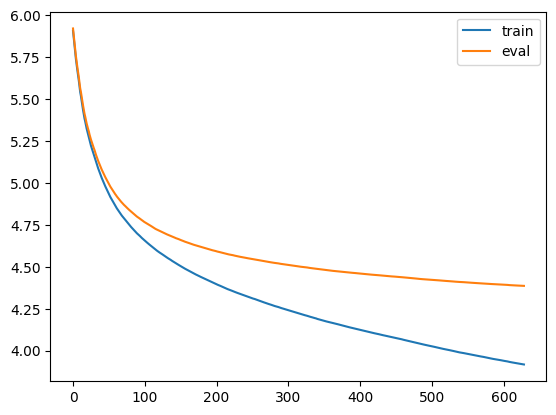

In [94]:
# retrieve performance metrics
results = model.evals_result()

# plot learning curves
plt.plot(results['validation_0']['rmse'], label='train')
plt.plot(results['validation_1']['rmse'], label='eval')
# show the legend
plt.legend()
# show the plot
plt.show()

In [96]:
# Retrieve the "gain" feature importance scores
importance_scores = model.feature_importances_

# Print the feature importance scores along with feature names
Importance_labels = np.argsort(importance_scores)[-30:]
#Importance_labels = Importance_labels[ (Importance_labels != 7328) & (Importance_labels != 7327)]
print(vectorizer.get_feature_names_out()[Importance_labels])
#print(importance_scores[Importance_labels])
#for feature, score in zip(vectorizer.get_feature_names_out(), importance_scores):
#    print(f"{feature}: {score}")
print(len(Importance_labels))

['actually' 'abrupt' 'abstrak' 'abbey' 'aben' 'abort' 'aarhus' 'abdul'
 'adelsmærk' 'adida' 'abc' 'aabspil' 'aarup' 'actionfilm' 'aakeson'
 'aagaard' 'absorb' 'aalbæk' 'abe' 'aabtræn' 'aag' 'aarestrup'
 'aalborgens' 'aar' 'aabenraa' 'aaen' 'aaberg' 'aalborg' 'aakjær' 'aab']
30


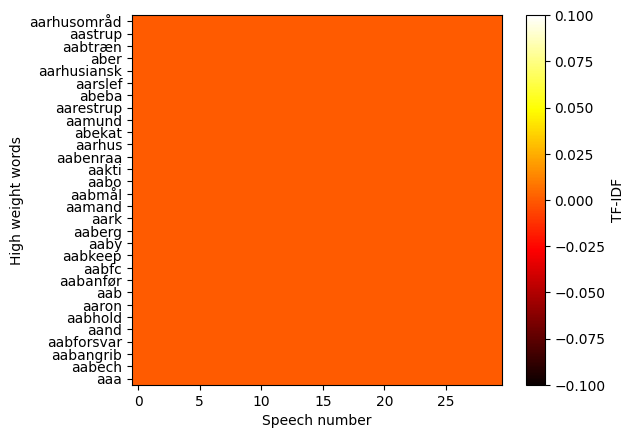

In [31]:
#https://hackernoon.com/document-term-matrix-in-nlp-count-and-tf-idf-scores-explained
vectorizer.get_feature_names_out()[Importance_labels]
Axis_values = vectorizer.get_feature_names_out()[Importance_labels]
Occ_matrix = X[:,Importance_labels].todense()[0:30,:]
y_axis = np.arange(30)
#plt.cmap('heat')
plt.imshow(Occ_matrix, cmap = 'hot')
plt.yticks(y_axis, Axis_values)
plt.xlabel('Speech document')
plt.ylabel('High weight words')
plt.xlabel('Speech number')
plt.colorbar(label = 'TF-IDF')
plt.show()

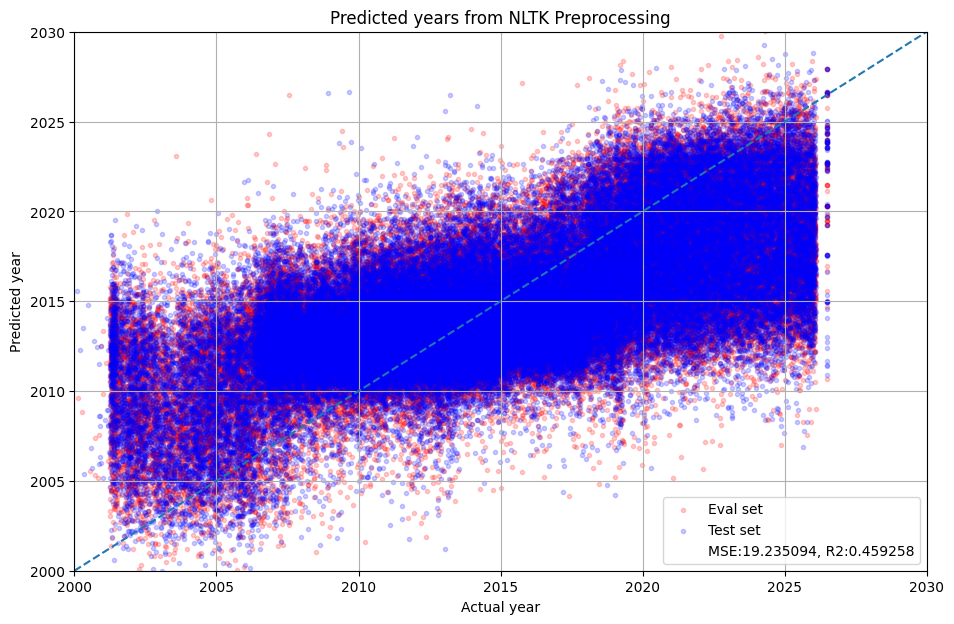

In [100]:

plt.figure(figsize = (11,7))

#plt.plot(y_pred,y_test, '.', label = 'Eval set')
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
#plt.plot(y_train_pred, y_train, '.', alpha = 0.3, c = 'orange', label = 'Train set')
#plt.errorbar(y_pred, y_eval, xerr =rmse, fmt = ',', c= 'lightblue', label = 'Eval set')
#plt.scatter(y_pred,y_eval, c = c_cluster)
plt.scatter(y_eval, y_pred, marker = '.', c = 'red', label = 'Eval set', alpha = 0.2)
plt.scatter(y_test, y_test_pred, marker = '.',c = 'blue', label = 'Test set', alpha = 0.2)

plt.plot([2000,2030],[2000,2030], '--')
plt.ylabel('Predicted year')
plt.xlabel('Actual year')
plt.xlim(2000,2030)
plt.ylim(2000,2030)

plt.plot([],[], ' ', label = f'MSE:{rmse:3f}, R2:{r2:3f}')
plt.grid()
plt.title('Predicted years from NLTK Preprocessing')
plt.legend()


<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Geniet\AppData\Local\Temp\ipykernel_12360\708554812.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.2f}, $\sigma$: {scale:.2f}')
C:\Users\Geniet\AppData\Local\Temp\ipykernel_12360\708554812.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.2f}, $\sigma$: {scale:.2f}')


Sum of observed counts: 5.300911861862765
Sum of expected counts: 77522.64128213446
Fitted t-distribution: pdf = 40.49, loc = 0.02, scale = 4.28
Chi-square statistic: 0.03
P-value: 1.0000


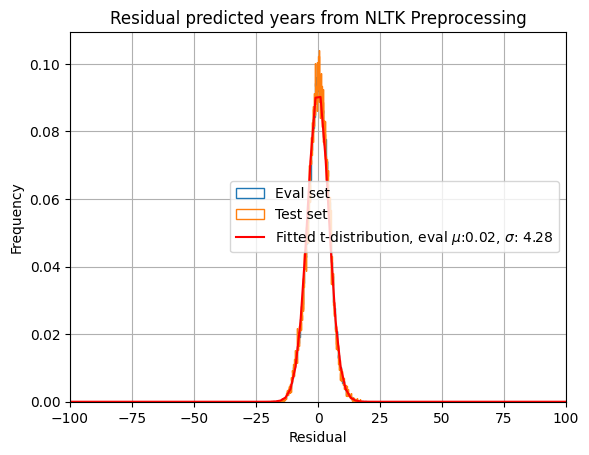

In [218]:
#def Gauss(x,a,b,c):
#    return( a*np.exp(-( (x-b)**2) / (2*c**2) ) )



#plt.plot(abs(y_train_pred -y_train), '.', alpha = 0.3, c = 'orange', label = 'Train set')
n_eval, bins_eval, patches_eval = plt.hist(y_pred-y_eval, bins = 200, density = True, histtype = 'step', label = 'Eval set')
n_test, bins_test, patches_test = plt.hist(y_pred_test-y_test, density = True, bins = 500, histtype = 'step', label = 'Test set')

#par_eval, cov_eval = curve_fit(Gauss, (bins_eval[:-1] + bins_eval[1:] )/2 , n_eval, p0 = [0.08, 0, 4])
#par_test, cov_test = curve_fit(Gauss, (bins_test[:-1] + bins_test[1:] )/2, n_test, p0 = [0.08, 0, 5])

pdf, loc, scale = t.fit(y_pred-y_eval)

pdf_values = t.pdf((bins_eval[:-1] + bins_eval[1:] )/2, pdf, loc, scale)
bin_width_eval = bins_eval[1] - bins_eval[0]
expected_counts = pdf_values * len(y_pred-y_eval) * bin_width_eval

print("Sum of observed counts:", np.sum(n_eval))
print("Sum of expected counts:", np.sum(expected_counts))
expected_counts = pdf_values * len(y_pred-y_eval) * bin_width_eval *(np.sum(n_eval)/np.sum(expected_counts))

# Step 5: Perform chi-square test
chi2_stat, p_value = chisquare(n_eval, f_exp=expected_counts)

print(f"Fitted t-distribution: pdf = {pdf:.2f}, loc = {loc:.2f}, scale = {scale:.2f}")
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

#print(len(n_eval),'\n', len(bins_eval[:-1]), '\n', patches_eval )
X_fit = np.linspace(-100,100, 100)
#plt.plot(X_fit, Gauss(X_fit, *par_eval), label = 'eval fit')
#plt.plot(X_fit, Gauss(X_fit, *par_test), label = 'test fit')
plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.2f}, $\sigma$: {scale:.2f}')

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.xlim(-100, 100)

plt.grid()
plt.title('Residual predicted years from NLTK Preprocessing')
plt.legend()

#print(par_eval, '\n', par_test)

#obs_eval = Gauss((bins_eval[:-1] + bins_eval[1:] )/2, *par_eval)

#chi2_stat, p_value = chisquare(obs_eval, f_exp=n_eval)
#print(chi2_stat, p_value)

Best parameters found:  {'gamma': np.float64(0.6348732858009982), 'learning_rate': np.float64(0.28145626428614795), 'max_depth': 11, 'n_estimators': 218, 'reg_alpha': np.float64(0.9810189966210203), 'reg_lambda': np.float64(0.8275041888291987), 'subsample': np.float64(0.9341066351050259)}

<h1> Multiclassification of article topics</h1>

In [162]:
X2_text = (vectorizer.fit_transform(df_topic_sort['text'])).astype(np.float32)
X2_lix = csr_matrix(df_topic_sort[['LIX']].astype(float).values)
#hstack([X_text, X_lix]) #,X_sermon])

X2 = hstack([X2_text, X2_lix]) #X2_text
y2 = df_topic_sort['topic']
print(f"Sparsity: {X2_text.nnz / np.prod(X2_text.shape):.3f}")
print("TF-IDF matrix shape:", X2.shape)

Sparsity: 0.001
TF-IDF matrix shape: (434564, 40535)


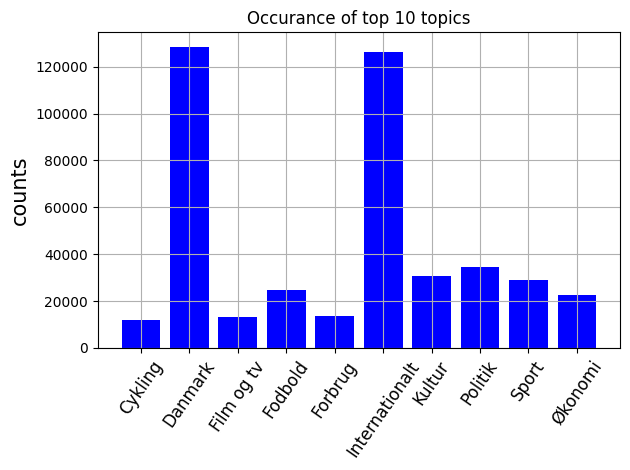

In [279]:
#plt.figure(figsize)
plt.xticks(rotation=55, fontsize = 12)
plt.ylabel('counts', fontsize = 15)
label ,counts = np.unique(y2, return_counts = True)
plt.bar(label, counts, color = 'blue')
plt.title('Occurance of top 10 topics')
plt.grid()
plt.tight_layout()

##### 2_lix

In [182]:
svd = TruncatedSVD(n_components=500,
             algorithm='randomized',
             n_iter=5,
             n_oversamples=10,
             power_iteration_normalizer='auto',
             random_state=42,
             )

X2_LSA = svd.fit_transform(X2)

print(svd.explained_variance_ratio_)
print(svd.explained_variance_ratio_.sum())
print(svd.singular_values_)

le = LabelEncoder()
y2_encoded = le.fit_transform(y2)

X2_train, X2_temp, y2_train, y2_temp = train_test_split(X2_LSA, y2_encoded, test_size=0.20, random_state=42, stratify = y2_encoded)
X2_eval, X2_test, y2_eval, y2_test = train_test_split(X2_temp, y2_temp, test_size=0.5, random_state=42, stratify = y2_temp)

_, X2_sample, _ , y2_sample = train_test_split(X2_train, y2_train, test_size = 100000, stratify = y2_train) #Creating a sample to optimise over.
print('Done')

[9.88083218e-01 5.85434699e-05 4.24981627e-05 3.50602711e-05
 3.24836315e-05 2.88151022e-05 2.63582885e-05 2.48732329e-05
 2.41599476e-05 2.17030317e-05 2.09488966e-05 2.04643744e-05
 2.03342094e-05 1.93061533e-05 1.85716307e-05 1.83471810e-05
 1.75809949e-05 1.74274588e-05 1.73221047e-05 1.66261036e-05
 1.61310333e-05 1.59802886e-05 1.57273862e-05 1.53981484e-05
 1.50423602e-05 1.46229495e-05 1.41619043e-05 1.37993143e-05
 1.35704399e-05 1.33361277e-05 1.28685509e-05 1.26512319e-05
 1.21818658e-05 1.18997587e-05 1.17809157e-05 1.15174680e-05
 1.13354820e-05 1.11342726e-05 1.10608065e-05 1.09113921e-05
 1.06895175e-05 1.06073014e-05 1.03526837e-05 1.02847068e-05
 1.01531359e-05 1.00709733e-05 9.93441140e-06 9.89060106e-06
 9.84640624e-06 9.73314274e-06 9.64647598e-06 9.54503888e-06
 9.41930132e-06 9.36802336e-06 9.33564558e-06 9.28484769e-06
 9.19014610e-06 9.18049613e-06 9.11411279e-06 9.00484932e-06
 8.95634171e-06 8.85435145e-06 8.81877188e-06 8.70529673e-06
 8.67466305e-06 8.641397

In [186]:
print("Class distribution in y2_eval:", np.unique(y2_eval, return_counts=True))

Class distribution in y2_eval: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 1180, 12823,  1309,  2460,  1357, 12625,  3070,  3453,  2908,
        2271]))


In [188]:
print("Explained variance:", svd.explained_variance_ratio_.sum())

Explained variance: 0.9911234747149809


In [190]:
X2_sample.shape

(100000, 500)

In [202]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, log_loss
from optuna.integration import XGBoostPruningCallback
import optuna
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight
from optuna.samplers import TPESampler

print('Running XGBoost version:', xgb.__version__)

evalset = [(X2_eval, y2_eval)]

def objective(trial):
    # Calculate class weights
    class_weights = dict(enumerate(len(y2_sample) / (len(np.unique(y2_sample)) * np.bincount(y2_sample))))
    sample_weight = compute_sample_weight(class_weight='balanced', y=y2_sample) #np.array([class_weights[label] for label in y2_sample])

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),  # More trees
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),  # Slower learning
        "max_depth": trial.suggest_int("max_depth", 4, 8, log = True),  # Shallower trees
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),  # Less conservative
        "gamma": trial.suggest_float("gamma", 0, 0.2),  # Less aggressive
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 0.5),  # Moderate L1
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 0.5),  # Moderate L2
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),  # More data per tree
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),  # More features
    }

    #import lightgbm as lgb

    #model = lgb.LGBMClassifier(
    #    objective="multiclass",
    #    class_weight="balanced",  # Works in multiclass!
    #    n_estimators=800,
    #    learning_rate=0.03,
    #    max_depth=6,
    #    random_state=42,

    # Create model with minimal logging configuration
    model = xgb.XGBClassifier(
        objective="multi:softprob",
        #class_weight= "balanced_subsample", #"balanced",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        importance_type="weight",
        **params,
        n_jobs=1,
        tree_method="hist",
        early_stopping_rounds=20,
        random_state=42,
        callbacks=[ XGBoostPruningCallback(trial,"validation_0-mlogloss")],
    )

    # Fit the model
    #pruning_callback = XGBoostPruningCallback(trial,"validation_0-mlogloss")
    model.fit(X2_sample, y2_sample, eval_set=evalset, verbose=2, sample_weight=sample_weight)

    # Get predictions and calculate log loss
    y2_pred_proba = model.predict_proba(X2_eval)
    logloss = log_loss(y2_eval, y2_pred_proba)
    return logloss

#################################################

study_name = "NLTK_clas_Art-study"
storage_name = f"sqlite:///{study_name}.db"
#optuna.delete_study(study_name=study_name, storage=storage_name)

study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    sampler=TPESampler(seed = 42, n_startup_trials=5)
)

# Run optimization
study.optimize(objective, n_trials=150)

##################################################

print("\nBest trial:")
trial = study.best_trial
print(f"  Log Loss: {trial.values[0]}")
print("Best hyperparameters:", study.best_params)
print("Best value:", study.best_value)


Running XGBoost version: 3.0.0


[I 2026-06-07 12:57:29,570] Using an existing study with name 'NLTK_clas_Art-study' instead of creating a new one.


[0]	validation_0-mlogloss:2.24152
[2]	validation_0-mlogloss:2.14253
[4]	validation_0-mlogloss:2.06776
[6]	validation_0-mlogloss:2.00349
[8]	validation_0-mlogloss:1.94263
[10]	validation_0-mlogloss:1.89077
[12]	validation_0-mlogloss:1.84357
[14]	validation_0-mlogloss:1.79954
[16]	validation_0-mlogloss:1.76084
[18]	validation_0-mlogloss:1.72523
[20]	validation_0-mlogloss:1.69352
[22]	validation_0-mlogloss:1.66431
[24]	validation_0-mlogloss:1.63807
[26]	validation_0-mlogloss:1.61229
[28]	validation_0-mlogloss:1.58819
[30]	validation_0-mlogloss:1.56555
[32]	validation_0-mlogloss:1.54557
[34]	validation_0-mlogloss:1.52612
[36]	validation_0-mlogloss:1.50854
[38]	validation_0-mlogloss:1.49345
[40]	validation_0-mlogloss:1.47718
[42]	validation_0-mlogloss:1.46356
[44]	validation_0-mlogloss:1.45009
[46]	validation_0-mlogloss:1.43692
[48]	validation_0-mlogloss:1.42466
[50]	validation_0-mlogloss:1.41271
[52]	validation_0-mlogloss:1.40242
[54]	validation_0-mlogloss:1.39155
[56]	validation_0-mloglos

[W 2026-06-07 14:26:46,469] Trial 206 failed with parameters: {'n_estimators': 689, 'learning_rate': 0.045562018319566265, 'max_depth': 7, 'min_child_weight': 4, 'gamma': 0.19390600335297892, 'reg_alpha': 0.28793662155073424, 'reg_lambda': 0.13222196000487477, 'subsample': 0.7020116145900651, 'colsample_bytree': 0.6107899905173602} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Geniet\AppliedML\AppliedML2026\appmlenv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Geniet\AppData\Local\Temp\ipykernel_13460\1714762141.py", line 57, in objective
    model.fit(X2_sample, y2_sample, eval_set=evalset, verbose=2, sample_weight=sample_weight)
  File "C:\Users\Geniet\AppliedML\AppliedML2026\appmlenv\Lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\Geniet\Ap

KeyboardInterrupt: 

In [204]:
study = optuna.create_study(study_name = study_name, 
                            storage = storage_name,
                            load_if_exists=True,
                            direction="minimize",
                            #pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
                           )

print("Best trial:")
trial = study.best_trial
print(f"  Log Loss: {trial.values[0]}")
#print(f"  Accuracy: {-trial.values[1]}") 

print("Best hyperparameters:", study.best_params)
#print("Best accuracy:", study.best_value)

[I 2026-06-07 14:26:57,623] Using an existing study with name 'NLTK_clas_Art-study' instead of creating a new one.


Best trial:
  Log Loss: 0.9680228467642897
Best hyperparameters: {'n_estimators': 539, 'learning_rate': 0.045822054368119675, 'max_depth': 8, 'min_child_weight': 4, 'gamma': 0.19614388158355484, 'reg_alpha': 0.2987950563030436, 'reg_lambda': 0.12666866769163798, 'subsample': 0.7016948750975935, 'colsample_bytree': 0.6112678952235817}


In [206]:
class_weights = dict(enumerate(len(y2_train) / (len(np.unique(y2_train)) * np.bincount(y2_train))))
sample_weight = compute_sample_weight(class_weight='balanced', y=y2_train)


model = xgb.XGBClassifier(objective='multi:softprob',
                         num_class=len(le.classes_),
                         eval_metric='mlogloss',
                         importance_type="gain",
                              
                         **study.best_params,
                              
                         n_jobs = 2,
                         tree_method = 'hist',
                         early_stopping_rounds = 20,
                         grow_policy = 'lossguide',
                         max_bin = 64,
                         random_state=42)

evalset = [(X2_train, y2_train), (X2_eval, y2_eval)]

model.fit(X2_train, y2_train, eval_set= evalset, verbose=2, sample_weight = sample_weight)
y2_pred_proba = model.predict_proba(X2_eval)
y2_pred =  model.predict(X2_eval)
logloss = log_loss(y2_eval, y2_pred_proba)
accuracy = accuracy_score(y2_eval, y2_pred)

print("\nClassification Report:")
print(classification_report(y2_eval, y2_pred))

print(f'log loss {logloss:.2f}')
print(f'accuracy {accuracy:.2f}')

[0]	validation_0-mlogloss:2.23566	validation_1-mlogloss:2.23776
[2]	validation_0-mlogloss:2.12671	validation_1-mlogloss:2.13289
[4]	validation_0-mlogloss:2.04373	validation_1-mlogloss:2.05379
[6]	validation_0-mlogloss:1.97365	validation_1-mlogloss:1.98720
[8]	validation_0-mlogloss:1.90715	validation_1-mlogloss:1.92417
[10]	validation_0-mlogloss:1.84976	validation_1-mlogloss:1.86970
[12]	validation_0-mlogloss:1.79817	validation_1-mlogloss:1.82088
[14]	validation_0-mlogloss:1.75036	validation_1-mlogloss:1.77577
[16]	validation_0-mlogloss:1.70747	validation_1-mlogloss:1.73577
[18]	validation_0-mlogloss:1.66840	validation_1-mlogloss:1.69951
[20]	validation_0-mlogloss:1.63316	validation_1-mlogloss:1.66676
[22]	validation_0-mlogloss:1.60085	validation_1-mlogloss:1.63695
[24]	validation_0-mlogloss:1.57141	validation_1-mlogloss:1.60991
[26]	validation_0-mlogloss:1.54314	validation_1-mlogloss:1.58414
[28]	validation_0-mlogloss:1.51635	validation_1-mlogloss:1.55973
[30]	validation_0-mlogloss:1.4

In [224]:
model.save_model('model_mclass.json')

In [207]:
y2_pred_proba = model.predict_proba(X2_test)
y2_pred =  model.predict(X2_test)
logloss = log_loss(y2_test, y2_pred_proba)
accuracy = accuracy_score(y2_test, y2_pred)

print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))

print(f'log loss {logloss:.2f}')
print(f'accuracy {accuracy:.2f}')


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1179
           1       0.76      0.63      0.69     12823
           2       0.60      0.66      0.63      1308
           3       0.66      0.70      0.68      2460
           4       0.41      0.58      0.48      1356
           5       0.82      0.77      0.80     12626
           6       0.47      0.53      0.50      3070
           7       0.54      0.72      0.62      3454
           8       0.66      0.61      0.63      2909
           9       0.44      0.60      0.50      2272

    accuracy                           0.68     43457
   macro avg       0.62      0.66      0.64     43457
weighted avg       0.70      0.68      0.68     43457

log loss 0.99
accuracy 0.68


In [220]:
importance_scores = model.feature_importances_

Importance_labels = np.argsort(importance_scores)[-30:]
print(vectorizer.get_feature_names_out()[Importance_labels])
print(len(Importance_labels))

['aab' 'achim' 'abolhosseini' 'aarø' 'aaen' 'aag' 'aalborgens' 'aabybro'
 'aarstid' 'abs' 'abbot' 'aap' 'aakeson' 'aar' 'aabtræn' 'aabenraa' 'aach'
 'aaby' 'aabmålmand' 'aabhold' 'aakjær' 'aalborgensisk' 'aabech' 'aabmål'
 'aarestrup' 'aabspil' 'aaja' 'aamund' 'aabforsvar' 'aaberg']
30


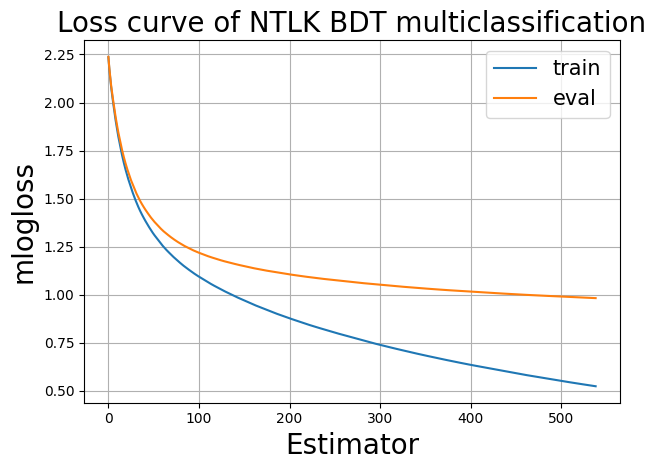

In [234]:
# retrieve performance metrics
results = model.evals_result()

# plot learning curves
plt.plot(results['validation_0']['mlogloss'], label='train')
plt.plot(results['validation_1']['mlogloss'], label='eval')
# show the legend
plt.xlabel('Estimator', fontsize = 20)
plt.ylabel('mlogloss', fontsize = 20)
plt.title('Loss curve of NTLK BDT multiclassification', fontsize = 20)
plt.grid()
plt.tight_layout()
plt.legend(fontsize = 15)
# show the plot
plt.show()

In [214]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve

# Get predicted probabilities
y2_probs = model.predict(X2_test)

# Compute precision-recall curve
#precision, recall, thresholds = precision_recall_curve(y2_test, y2_probs)

# Find threshold that maximizes F1 score
#f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
#best_threshold = thresholds[np.argmax(f1_scores)]

display = RocCurveDisplay.from_predictions(
    y2_test.ravel(),
    y2_probs.ravel(),
    name="micro-average OvR",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Micro-averaged One-vs-Rest\nReceiver Operating Characteristic",
)
#auc = roc_auc_score(y2_test, y2_probs, multi_class='ovr')
#print(f"Optimal threshold: {best_threshold:.4f}")
#disp = RocCurveDisplay.from_predictions(y2_test, y2_probs,  name="CNN", label = f'AUC = {auc:.3f})')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
#plt.ylabel('True positive rate', fontsize = 20)
#plt.xlabel('False positive rate', fontsize = 20)
plt.legend(fontsize = 15)
plt.title('NLTK Speech classification BDT')
plt.grid()

ValueError: The target y is not binary. Got multiclass type of target.

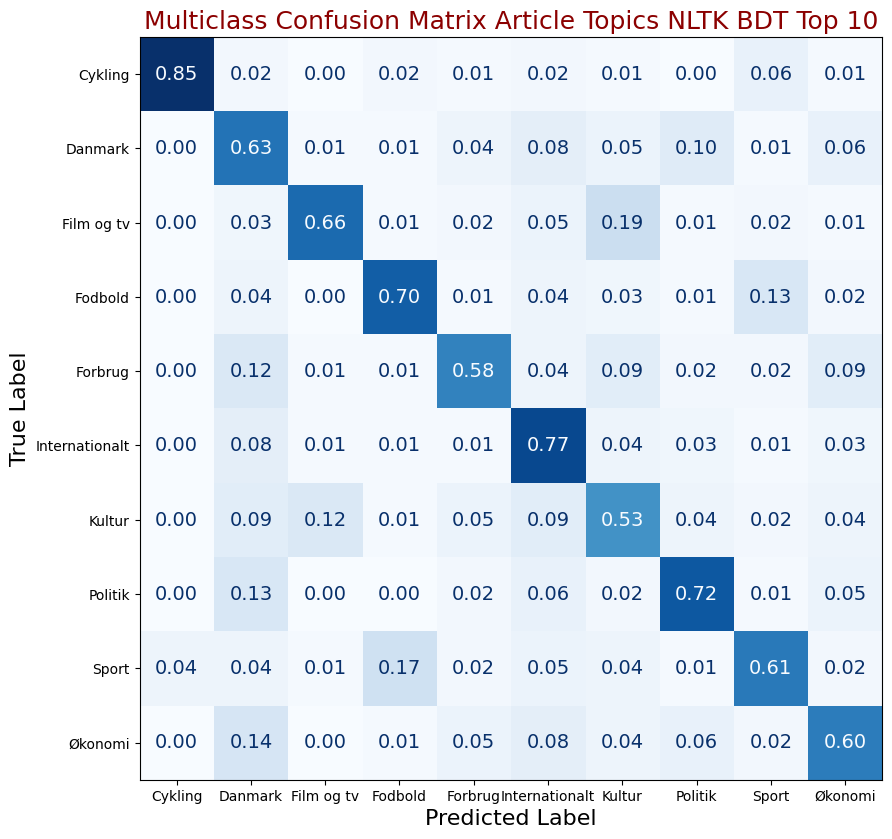

In [216]:
cm = confusion_matrix(
    y2_test,
    y2_probs,
    normalize="true"
)

# Force 2 decimals
cm = np.round(cm, 2)

classes = le.classes_

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    xticks_rotation=0,
    cmap=plt.cm.Blues,
    colorbar=False,

    values_format=".2f"   # FORCE 2 DECIMALS
)

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Multiclass Confusion Matrix Article Topics NLTK BDT Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "Predicted Label",
    fontsize=16
)
plt.ylabel(
    "True Label",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [218]:

classes = np.unique(df_topic_sort['topic'].values)
cm = multilabel_confusion_matrix(y2_test, y2_probs, labels = classes)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
#fig, ax = plt.subplots(figsize=(8, 8))
#disp.plot(ax = ax, xticks_rotation=0, cmap=plt.cm.Blues, colorbar=False)
#for t in disp.text_.ravel():
#    t.set_text(f"{float(t.get_text()):.3f}")
#    t.set_fontsize(16)
plt.title("NLTK BDT model", fontsize=18, color="darkred")
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)
plt.savefig("confusion_matrix_speeches.png", dpi=300)
plt.show()

TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']